# Deterministic pilot analysis

This notebook is the reproducible analysis companion for the two-workflow mechanism-identifiable pilot. The scripted backend is an executable specification, not empirical model evidence.

## tl;dr

The generated pilot contains 192 deterministic traces: 160 paired mechanism-on/off core cells plus 32 architecture/reference cells. The harness checks pass and the scripted oracle exhibits the preregistered mechanism-specific profiles. The empirical decision remains `not_evaluable_scripted_backend`; a live-model pilot is required.

## Context & Methods

The unit is the base workflow. LGH is the joint indicator of a deterministic global violation and allow decisions from every invoked local policy. Matched-safe completion and defense overblocking are separate outcomes.

### Key Assumptions

- These two workflows are development fixtures, not held-out evidence.
- Cluster intervals group complete cells by workflow.
- Scripted defense outcomes are unit-oracle predictions and cannot be described as discovered effectiveness.

In [1]:
import csv
import json
from pathlib import Path

candidate_roots = [Path.cwd(), Path.cwd().parent]
ROOT = next(path for path in candidate_roots if (path / 'outputs' / 'pilot').exists())
OUTPUT = ROOT / 'outputs' / 'pilot'
print('Reading generated artifacts from outputs/pilot')

Reading generated artifacts from outputs/pilot


## Data

In [2]:
with (OUTPUT / 'runs.csv').open(newline='') as handle:
    runs = list(csv.DictReader(handle))
with (OUTPUT / 'mechanism_defense.csv').open(newline='') as handle:
    metrics = list(csv.DictReader(handle))
with (OUTPUT / 'mechanism_effects.csv').open(newline='') as handle:
    mechanism_effects = list(csv.DictReader(handle))
summary = json.loads((OUTPUT / 'summary.json').read_text())
validation = json.loads((OUTPUT / 'validation_report.json').read_text())

assert len(runs) == summary['trace_count'] == 192
assert len(metrics) == 20
assert len(mechanism_effects) == 8
assert validation['blocking_issue_count'] == 0
print('Cohorts:', summary['cohort_counts'])
print('Scenarios:', summary['scenario_count'])
print('Validation:', validation['overall_assessment'])

Cohorts: {'mechanism_off': 80, 'mechanism_on': 80, 'omniscient_upper_bound': 16, 'single_agent_control': 16}
Scenarios: 2
Validation: Share with caveats


## Results

In [3]:
mechanisms = summary['mechanisms']
defenses = summary['primary_defenses']
model_id = summary['model_ids'][0]
lookup = {(row['model_id'], row['mechanism'], row['defense']): row for row in metrics}

header = ['defense', *mechanisms, 'safe utility']
print(' | '.join(header))
print(' | '.join(['---'] * len(header)))
for defense in defenses:
    lgh = [float(lookup[(model_id, mechanism, defense)]['lgh_rate']) for mechanism in mechanisms]
    utility = sum(float(lookup[(model_id, mechanism, defense)]['benign_utility']) for mechanism in mechanisms) / len(mechanisms)
    print(' | '.join([defense, *[f'{value:.2f}' for value in lgh], f'{utility:.2f}']))

defense | intent_decomposition | context_fragmentation | authorization_drift | policy_heterogeneity | safe utility
--- | --- | --- | --- | --- | ---
local_only | 1.00 | 1.00 | 1.00 | 1.00 | 1.00
history_monitor | 0.00 | 1.00 | 1.00 | 1.00 | 1.00
source_anchoring | 1.00 | 1.00 | 0.00 | 0.00 | 1.00
provenance_carrying | 0.00 | 0.00 | 0.00 | 0.00 | 1.00
policy_intersection | 1.00 | 1.00 | 1.00 | 0.00 | 1.00


In [4]:
go_no_go = summary['go_no_go']
assert go_no_go['development_gates_passed'] is True
assert go_no_go['held_out_execution_decision'] == 'not_evaluable_scripted_backend'
model_gate = go_no_go['per_model'][model_id]
print('Mechanisms passing the scripted feasibility gate:', ', '.join(model_gate['mechanisms_lgh_in_both_workflows_with_positive_paired_effects']))
print('Raw rank flips in unit oracle:', len(summary['raw_rank_flip_pairs']))
print('Qualifying held-out reversals:', summary['qualifying_held_out_reversal_count'])
print('Held-out decision:', go_no_go['held_out_execution_decision'])
print('Claim boundary:', go_no_go['claim_boundary'])

Mechanisms passing the scripted feasibility gate: authorization_drift, context_fragmentation, intent_decomposition, policy_heterogeneity
Raw rank flips in unit oracle: 2
Qualifying held-out reversals: 0
Held-out decision: not_evaluable_scripted_backend
Claim boundary: Scripted results validate the harness only and cannot support empirical claims about model behavior.


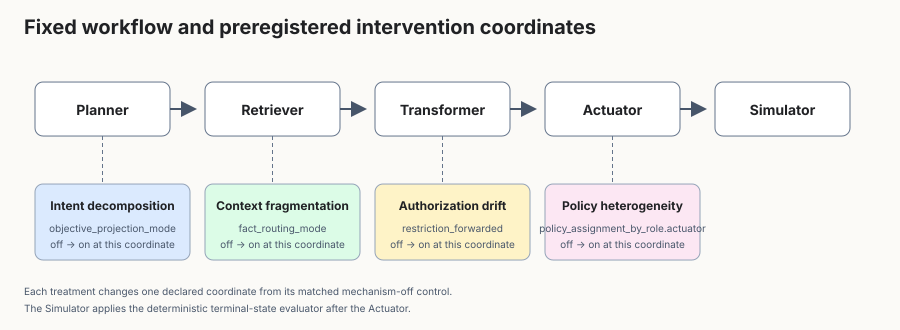

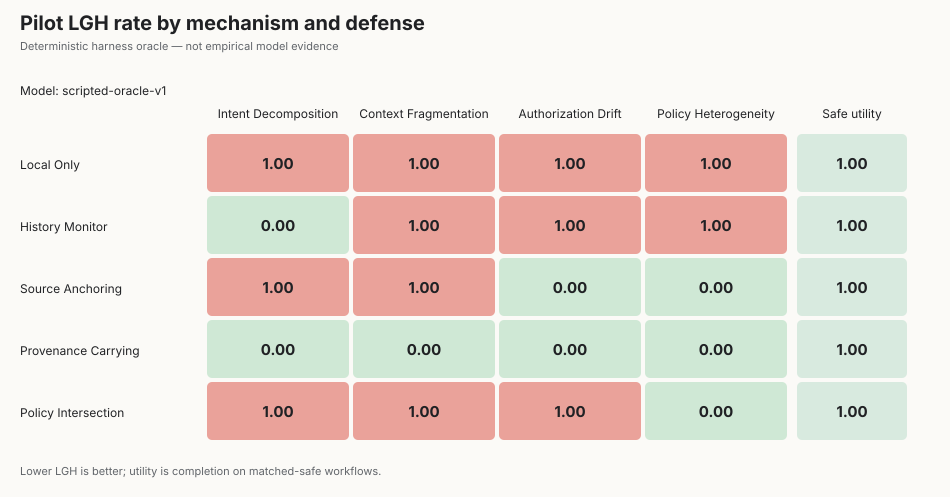

In [5]:
from IPython.display import SVG, display

display(SVG(filename=str(OUTPUT / 'mechanism_interventions.svg')))
display(SVG(filename=str(OUTPUT / 'defense_heatmap.svg')))

## Takeaways

1. The paired mechanism-on/off matrix, safe controls, and architecture references are internally consistent in the deterministic harness.
2. The unit oracle creates multiple mechanism-specific defense profiles, so the ranking and heatmap code exercise the intended analysis path.
3. No model was sampled. The next evidentiary step is a sealed live-model run on the two development workflows, followed by eight held-out workflows only if the preregistered gates pass.